<a href="https://colab.research.google.com/github/danish2k04/Getting-into-Pytorch-Deep-Learning/blob/main/Multiclass_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Building a multiclass classification

In [1]:
import requests
from pathlib import Path

# Download helper function from LEarn Pytorch repo (if it's not already downloaded)
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exits, skipping downloading")
else:
  print("Downloading helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)


from helper_functions import plot_predictions, plot_decision_boundary

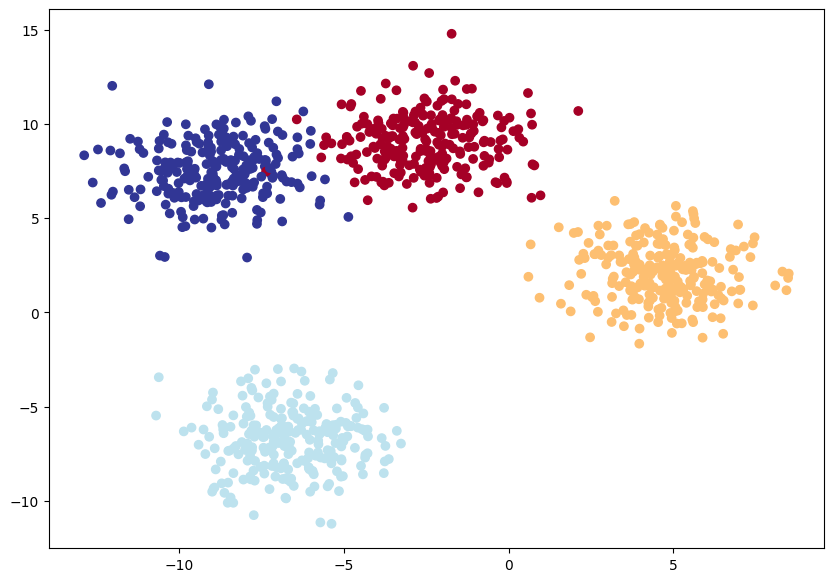

In [2]:
import torch
import matplotlib.pyplot as plt
import torch.nn as nn
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

# Set the hyperparameters for data creation
NUM_CLASSES = 4
NUM_FEATURES = 2
RANDOM_SEED = 42

# 1. Create multi_class data
X_blob, y_blob = make_blobs(n_samples=1000,
                            n_features=NUM_FEATURES,
                            centers=NUM_CLASSES,
                            cluster_std=1.5, # givet the little shape up
                            random_state=RANDOM_SEED)

# 2. Turn the data into tensors
X_blob = torch.from_numpy(X_blob).type(torch.float)
y_blob = torch.from_numpy(y_blob).type(torch.LongTensor)

# 3. Split into train and test
X_blob_train, X_blob_test, y_blob_train, y_blob_test = train_test_split(X_blob,
                                                                        y_blob,
                                                                        test_size=0.2,
                                                                        random_state=RANDOM_SEED)

# 4. plot data (Visualize)
plt.figure(figsize=(10, 7))
plt.scatter(X_blob[:, 0], X_blob[:, 1], c=y_blob, cmap=plt.cm.RdYlBu);


### Building a multi-class Classificaiton model

In [3]:
# Create device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"

device

'cpu'

In [4]:
# Build a multi-class classification model
class BlobModel(nn.Module):
  def __init__(self, input_features, output_features, hidden_units=8):
    super().__init__()
    self.linear_layer_stack = nn.Sequential(
        nn.Linear(in_features=input_features, out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units, out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units, out_features=output_features)
    )

  def forward(self, x):
    return self.linear_layer_stack(x)

# Create an instance of Blob model and sent it to target device
model = BlobModel(input_features=2,
                  output_features=4,
                  hidden_units=8).to(device)

model



BlobModel(
  (linear_layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=4, bias=True)
  )
)

### Create a loss function and optimizer

In [5]:
# Create a Loss Function
loss_fn = nn.CrossEntropyLoss()

# Create an optimizer
optimizer = torch.optim.SGD(params=model.parameters(),
                            lr=0.1)


In [6]:
# Calculate Accuracy
def accuracy_fn(y_true, y_preds):
  correct = torch.eq(y_true, y_preds).sum().item()
  acc = (correct/len(y_preds)) * 100
  return acc

In [7]:
# Getting prediction for the model
#Logits( Raw output) -> pred prob(using torch.softmax) -> pred labels (take the argmax for the prediction probabilities)
model.eval()
with torch.inference_mode():
  y_logits = model(X_blob_test)

print(y_logits[:5])

tensor([[ 0.1553,  0.6410,  1.2708,  0.4551],
        [ 0.1314,  0.5940,  0.4423,  0.0586],
        [-0.5717, -0.6102,  0.0721,  0.0074],
        [-0.1415,  0.1586,  0.5889, -0.0797],
        [ 0.4541,  1.2031,  1.9507,  1.0638]])


In [8]:
# Convert our model's logits output to predictiopn
y_pred_prob = torch.softmax(y_logits, dim=1)
print(y_logits[:5])
print(y_pred_prob[:5])


tensor([[ 0.1553,  0.6410,  1.2708,  0.4551],
        [ 0.1314,  0.5940,  0.4423,  0.0586],
        [-0.5717, -0.6102,  0.0721,  0.0074],
        [-0.1415,  0.1586,  0.5889, -0.0797],
        [ 0.4541,  1.2031,  1.9507,  1.0638]])
tensor([[0.1423, 0.2313, 0.4343, 0.1921],
        [0.2048, 0.3253, 0.2795, 0.1904],
        [0.1770, 0.1703, 0.3369, 0.3158],
        [0.1822, 0.2459, 0.3781, 0.1938],
        [0.1061, 0.2245, 0.4741, 0.1953]])


In [9]:
torch.sum(y_pred_prob[0])

tensor(1.)

In [10]:
torch.max(y_pred_prob[0])

tensor(0.4343)

In [11]:
torch.argmax(y_pred_prob[0])

tensor(2)

In [12]:
# Convert our model's prediction into prediction probabilities to prediction labels
y_preds = torch.argmax(y_pred_prob, dim=1)
y_preds

tensor([2, 1, 2, 2, 2, 1, 2, 2, 3, 2, 2, 2, 2, 2, 2, 1, 1, 2, 1, 1, 2, 2, 2, 2,
        2, 2, 1, 2, 2, 2, 1, 2, 2, 1, 2, 2, 2, 1, 2, 2, 2, 1, 1, 2, 2, 2, 2, 2,
        2, 1, 2, 2, 2, 2, 1, 2, 2, 2, 1, 2, 2, 2, 1, 2, 2, 2, 2, 1, 1, 2, 2, 1,
        1, 1, 2, 1, 1, 1, 2, 2, 2, 3, 2, 2, 1, 1, 3, 1, 1, 2, 1, 1, 2, 1, 1, 1,
        2, 2, 1, 2, 2, 2, 2, 2, 2, 1, 2, 2, 1, 2, 2, 2, 2, 3, 3, 1, 2, 2, 2, 2,
        2, 1, 2, 2, 2, 2, 2, 2, 3, 1, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 1, 2, 2, 2, 2, 1, 2, 2, 2, 1, 1, 2, 2, 3, 2, 1, 2, 2, 1, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 2, 2, 2,
        2, 1, 3, 2, 1, 2, 3, 2])

In [13]:
epochs = 100

torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed(RANDOM_SEED)

X_blob_train, y_blob_train = X_blob_train.to(device), y_blob_train.to(device)
X_blob_test, y_blob_test = X_blob_test.to(device), y_blob_test.to(device)

for epoch in range(epochs):
  model.train()

  # forward pass
  y_pred_logits = model(X_blob_train)
  y_preds = torch.softmax(y_pred_logits, dim=1).argmax(dim=1)

  # calculate loss
  loss = loss_fn(y_pred_logits, y_blob_train)
  acc = accuracy_fn(y_true=y_blob_train, y_preds=y_preds)

  # zero grade, backpropagation, optimizer step
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  model.eval()
  with torch.inference_mode():
    test_logits = model(X_blob_test) # Corrected from y_blob_test to X_blob_test
    test_preds = torch.softmax(test_logits, dim=1).argmax(dim=1)

    test_loss = loss_fn(test_logits, y_blob_test)
    test_acc = accuracy_fn(y_true=y_blob_test, y_preds=test_preds)

    if epoch % 10 == 0:
      print(f'Epoch: {epoch} | Train Loss: {loss:.4f} | Trainig Accuracy: {acc:2f}% | Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.2f}%\n')


Epoch: 0 | Train Loss: 1.5802 | Trainig Accuracy: 20.250000% | Test Loss: 1.1173 | Test Accuracy: 45.00%

Epoch: 10 | Train Loss: 0.3328 | Trainig Accuracy: 98.625000% | Test Loss: 0.2838 | Test Accuracy: 99.50%

Epoch: 20 | Train Loss: 0.1283 | Trainig Accuracy: 99.250000% | Test Loss: 0.1139 | Test Accuracy: 99.00%

Epoch: 30 | Train Loss: 0.0777 | Trainig Accuracy: 99.250000% | Test Loss: 0.0686 | Test Accuracy: 99.00%

Epoch: 40 | Train Loss: 0.0580 | Trainig Accuracy: 99.250000% | Test Loss: 0.0501 | Test Accuracy: 99.00%

Epoch: 50 | Train Loss: 0.0479 | Trainig Accuracy: 99.250000% | Test Loss: 0.0405 | Test Accuracy: 99.00%

Epoch: 60 | Train Loss: 0.0420 | Trainig Accuracy: 99.250000% | Test Loss: 0.0347 | Test Accuracy: 99.50%

Epoch: 70 | Train Loss: 0.0381 | Trainig Accuracy: 99.250000% | Test Loss: 0.0307 | Test Accuracy: 99.50%

Epoch: 80 | Train Loss: 0.0353 | Trainig Accuracy: 99.250000% | Test Loss: 0.0278 | Test Accuracy: 99.50%

Epoch: 90 | Train Loss: 0.0332 | Train

In [14]:
# Making and evaluating prediction
model.eval()
with torch.inference_mode():
  y_logits = model(X_blob_test)
  y_pred_probs = torch.softmax(y_logits, dim=1).argmax(dim=1)

y_pred_probs[:10]

tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0])

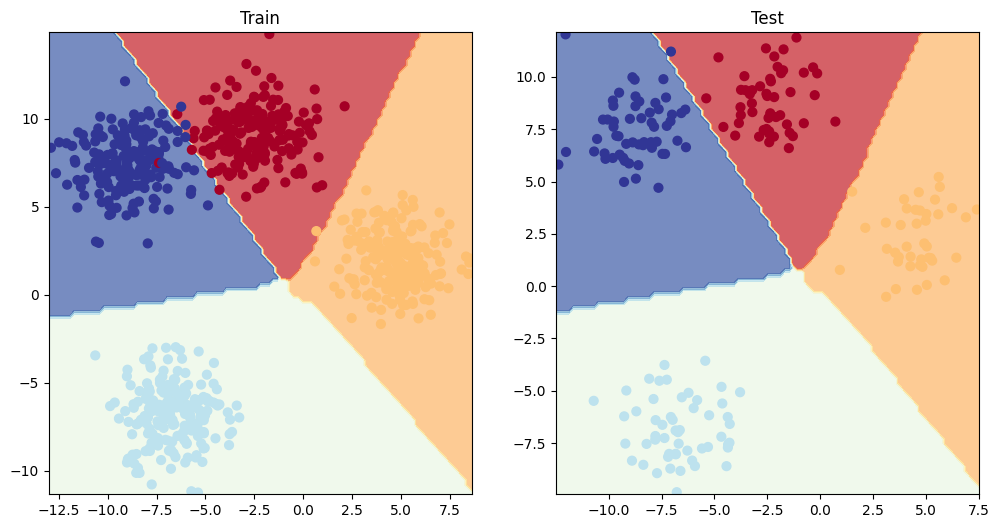

In [15]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model, X_blob_train, y_blob_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model, X_blob_test, y_blob_test)

In [16]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 8.0 MB/s eta 0:00:00


In [17]:
from torchmetrics import Accuracy

# Setup metrics

torchmetrics_accuracy = Accuracy(task='multiclass', num_classes=NUM_CLASSES).to(device)

# Calculate Accuracy
torchmetrics_accuracy(y_pred_probs, y_blob_test)

tensor(0.9950)